# 01 - Prétraitement des données

Ce notebook détaille le chargement, le filtrage et la préparation des données des capteurs mobiles pour l'entraînement du modèle.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ajout du dossier src au path
sys.path.append('../src')
from utils import load_dataset

## 1. Chargement des données

Nous chargeons l'ensemble du dataset à partir des dossiers `data/perfect` et `data/imperfect`.

In [2]:
base_path = '../data'
X, y = load_dataset(base_path)

print(f"Nombre de fenêtres : {len(X)}")
print(f"Dimensions de l'entrée : {X.shape}") # (N, seq_len, channels)
print(f"Distribution des classes : {np.bincount(y.astype(int))}")

Nombre de fenêtres : 65
Dimensions de l'entrée : (65, 100, 6)
Distribution des classes : [15 50]


## 2. Visualisation des signaux

Visualisons un échantillon de curl parfait vs imparfait.

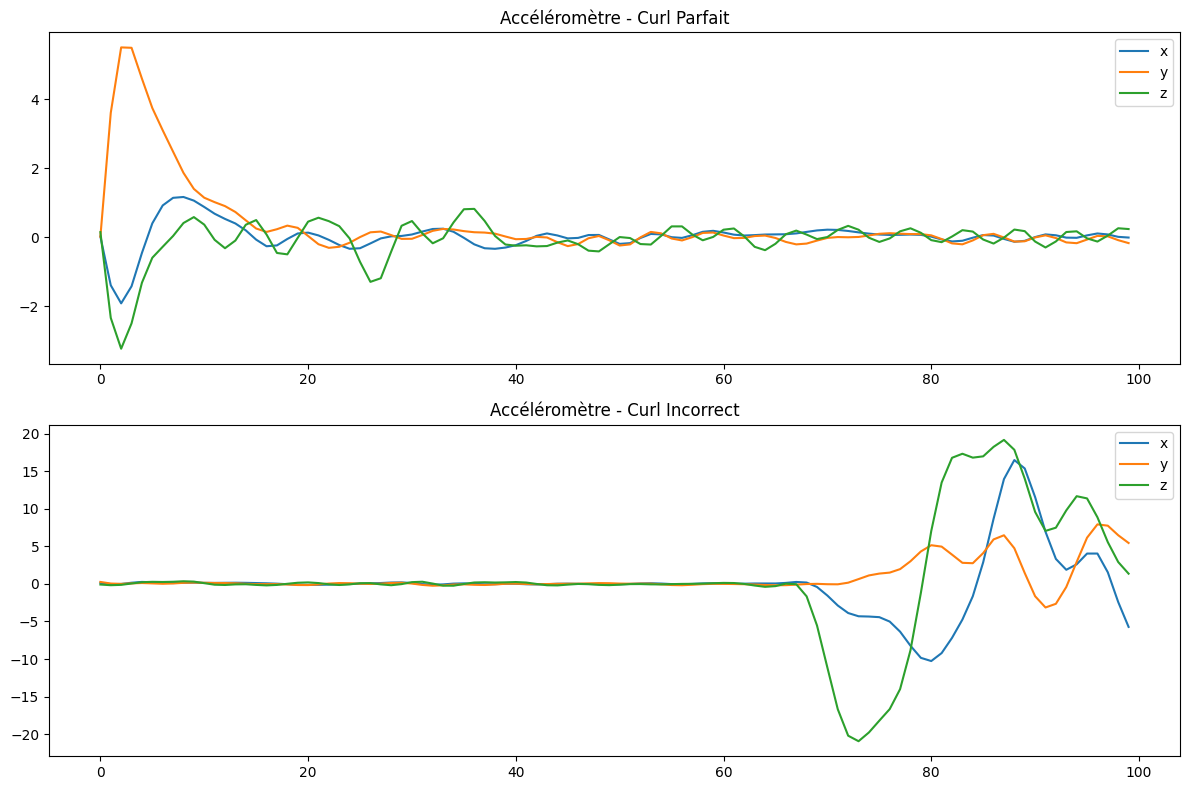

In [3]:
idx_perfect = np.where(y == 1)[0][0]
idx_imperfect = np.where(y == 0)[0][0]

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(X[idx_perfect][:, :3])
ax[0].set_title("Accéléromètre - Curl Parfait")
ax[0].legend(['x', 'y', 'z'])

ax[1].plot(X[idx_imperfect][:, :3])
ax[1].set_title("Accéléromètre - Curl Incorrect")
ax[1].legend(['x', 'y', 'z'])

plt.tight_layout()
plt.show()

## 3. Préparation pour le format PyTorch

PyTorch Conv1D attend une entrée de forme `(batch, channels, seq_len)`. Nos données sont actuellement `(N, seq_len, channels)`.

In [4]:
X_torch = np.transpose(X, (0, 2, 1))
print(f"Dimensions finales pour PyTorch : {X_torch.shape}")

Dimensions finales pour PyTorch : (65, 6, 100)
